# Process Trees from DMBD dataset

From LLNL page:

```
In addition to the ACME datasets, we also have the Dynamic Malware Behavior Dataset. This dataset is derived from 65,416 software samples with comprehensive execution logs. It can be used for training and evaluating machine learning models to distinguish between malicious and benign software based on their runtime behavior, with baseline accuracy of 95% that researchers are challenged to surpass.
```


In [1]:
import pandas as pd
import numpy as np
import igraph as ig
from collections import Counter
import matplotlib.pyplot as plt
import tqdm

## our matching algorithm
import sys
import os
sys.path.insert(0,os.path.abspath('../Matching'))
import igraph_io as igio
import fast_match as fm  ## fast version


## Build the process trees

Build edges ```parent --> guid```

Process names are all hashes

We'll use eitherthe ```malicious``` or ```test``` label for our exepriments.


In [2]:
# Read the entire feather file (prepared from other notebook)
df_tree = pd.read_feather('Data/all_trees.feather')

# Display the first few rows
print(df_tree.head())


        guid     parent process_name               timestamp  image_loads  \
0  G10154306              P76293.exe                     NaT            0   
1   G4029480  G10154306   P71830.exe 2024-08-24 16:31:37.055            0   
2  G18232545   G4029480   P85969.exe 2024-08-24 16:31:37.241            0   
3   G3413406  G18232545    P4164.exe 2024-08-24 16:31:37.338            0   
4  G20155766   G3413406   P51509.exe 2024-08-24 16:31:37.399            0   

   file_ops  network_connects experiment  malicious  test  
0         0                 0         E0       True  True  
1         0                 0         E0       True  True  
2         0                 0         E0       True  True  
3         0                 0         E0       True  True  
4         0                 0         E0       True  True  


In [3]:
Counter(df_tree.process_name)

Counter({'P122595.exe': 63207,
         'P46928.exe': 63183,
         'P4172.exe': 33618,
         'P76293.exe': 30897,
         'P64649.exe': 24788,
         'P136967.exe': 7886,
         'P66762.exe': 4062,
         'P82899.exe': 3526,
         'P135816.exe': 3515,
         None: 3201,
         'P82726.exe': 3116,
         'P7819.exe': 2923,
         'P19780.exe': 2403,
         'P93992.exe': 2096,
         'P23890.exe': 1996,
         'P40247.exe': 1752,
         'P97157.exe': 1745,
         'P136179.exe': 1720,
         'P43225.exe': 1708,
         'P81309.exe': 1682,
         'P97367.exe': 1681,
         'P144382.exe': 1678,
         'P140105.exe': 1642,
         'P37897.exe': 1615,
         'P23640.exe': 1522,
         'P59187.exe': 1509,
         'P50580.exe': 1451,
         'P91002.exe': 1417,
         'P125661.exe': 1330,
         'P120670.exe': 1318,
         'P143403.exe': 1316,
         'P25343.exe': 1316,
         'P55052.exe': 1312,
         'P52248.exe': 1312,
         '

In [4]:
df_roots = df_tree[df_tree.parent=='']
df_tree = df_tree[df_tree.parent!='']
print('number of root nodes:',df_roots.shape[0])

## node dictionaries
child = set(df_tree.guid)
parent = set(df_tree.parent) ## Can be 'None', we'll delete later
nodes = parent.union(child)
print('number of nodes:',len(nodes))
nodes_dict = {v:k for k,v in enumerate(nodes)}
inv_nodes_dict = {k:v for k,v in enumerate(nodes)}


number of root nodes: 34097
number of nodes: 843840


In [5]:
## build directed graph from edgelist
child = [nodes_dict[x] for x in df_tree.guid]
parent = [nodes_dict[x] for x in df_tree.parent]
edges = np.array([parent,child]).T
G = ig.Graph.TupleList(edges, directed=True)
G = G.simplify()
G.vs['guid'] = [inv_nodes_dict[int(x)] for x in G.vs['name']]
print(G.vcount() ,'nodes and', G.ecount(),'edges')


843840 nodes and 809743 edges


In [6]:
## add a few attributes
_dict = dict(zip(df_tree.guid, df_tree.parent))
G.vs["parent"] = [_dict.get(guid, "") for guid in G.vs["guid"]]

_dict = dict(zip(df_tree.guid, df_tree.malicious))
_dict.update(dict(zip(df_roots.guid, df_roots.malicious)))
G.vs["malicious"] = [_dict.get(guid, "") for guid in G.vs["guid"]]

G.vs['color'] = 'black'
for v in G.vs:
    if v['malicious']:
        v['color'] = 'red'

_dict = dict(zip(df_tree.guid, df_tree.process_name))
_dict.update(dict(zip(df_roots.guid, df_roots.process_name)))
G.vs["process"] = [_dict.get(guid, "") for guid in G.vs["guid"]]

_dict = dict(zip(df_tree.guid, df_tree.test))
_dict.update(dict(zip(df_roots.guid, df_roots.test)))
G.vs["test"] = [_dict.get(guid, "") for guid in G.vs["guid"]]

print('malicious label:',Counter(G.vs['malicious']))
print('test label:',Counter(G.vs['test']))

malicious label: Counter({True: 768895, False: 74945})
test label: Counter({True: 501489, False: 342351})


### Process trees and EDA

In [7]:
## Trees
Trees = G.connected_components(mode="weak")
G.vs['tree'] = Trees.membership
print('largest trees:', Counter(G.vs['tree']).most_common(5))


largest trees: [(9828, 4529), (19944, 4529), (27953, 4529), (1781, 4528), (22794, 4066)]


In [8]:
## trees with malicious label(s)
## either all or no node are malicious in any given tree
_df = pd.DataFrame( np.array([Trees.graph.vs['tree'] , Trees.graph.vs['malicious']]).T,columns=['tree','malicious'])
print('mean number of malicious nodes:',Counter(_df.groupby(by='tree')['malicious'].mean().to_list()))
tree_is_malicious = np.array(_df.groupby(by='tree')['malicious'].sum().to_list())


mean number of malicious nodes: Counter({1.0: 24603, 0.0: 9495})


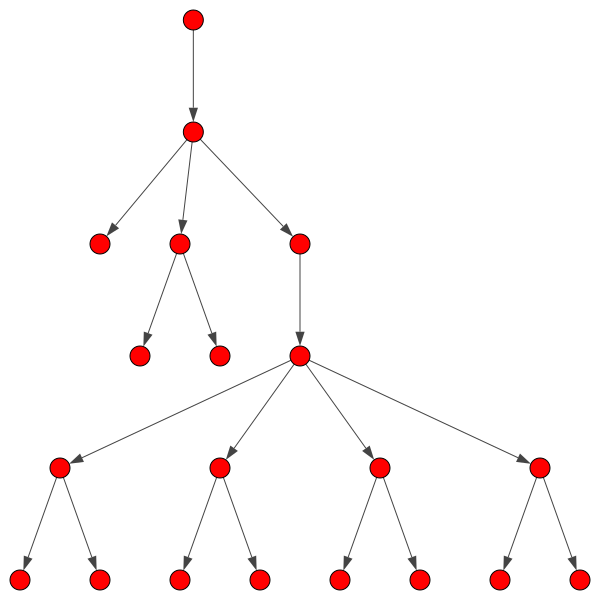

In [9]:
## example - malicious tree
idx = np.where( (np.array(Trees.sizes())==20) & (tree_is_malicious>0) )[0][0]
sg = Trees.subgraph(idx)
ly = sg.layout_reingold_tilford()
ig.plot(sg, layout=ly, vertex_label_size=0)


In [10]:
# Tree depth distribution
depths = np.empty(len(Trees), dtype="int64")
L = []
for tree_id in tqdm.trange(len(Trees)):
    tree = Trees.subgraph(tree_id)
    root = np.argmin(np.array(tree.degree(mode='in')))
    depth = max(tree.distances(root)[0]) # Trees are padded with extra start root
    depths[tree_id] = depth
    L.append([tree_id, tree.vcount(), sum(tree.vs['malicious']), depth, sum(tree.vs['test']) ])
G.vs['tree_depth'] = [depths[i] for i in G.vs['tree']]
_df = pd.DataFrame(L, columns=['tree','size','malicious','depth', 'test'])
_df['has_malicious'] = (_df['malicious']>0)
_df.head(5)


100%|██████████| 34098/34098 [16:41<00:00, 34.06it/s]


,tree,size,malicious,depth,test,has_malicious
0,0,147,147,146,147,True
1,1,463,463,462,463,True
2,2,6,6,3,0,True
3,3,3,0,2,0,False
4,4,3,3,2,0,True


#### It turns out that tree depth is a strong feature to identify malicious trees ...


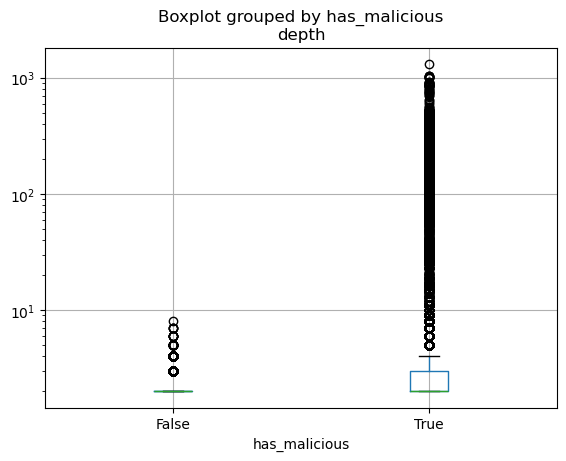

In [11]:
ax = _df.boxplot(column="depth", by="has_malicious", showfliers=True)
ax.set_yscale("log")


In [12]:
## most tree are shallow, a few are very deep
print('common depth:\n',Counter(depths).most_common(5))
print('deepest:',max(depths))
## max depth - non-malicious trees
print('deepest non-malicious:',max(_df[_df.has_malicious==False]['depth']))


common depth:
 [(np.int64(2), 24272), (np.int64(3), 3471), (np.int64(4), 1626), (np.int64(9), 638), (np.int64(5), 563)]
deepest: 1317
deepest non-malicious: 8


## Matching algorithm

In [13]:
## select trees of depth 3+
malicious_trees = list(_df[ (_df.depth>=3) & (_df.has_malicious) ]['tree'])
non_malicious_trees = list(_df[ (_df.depth>=3) & (_df.has_malicious == False) ]['tree'])
Trees.graph.vs['label_color'] = Trees.graph.vs['color']


In [14]:
%%time
Graphs = []
TreeData = []
nmt = 0

for i in malicious_trees:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        Graphs.append(sg)
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        nmt += 1

for i in non_malicious_trees:
    sg = Trees.subgraph(i)
    Graphs.append(sg)
    TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))

## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]
       

CPU times: user 4min 47s, sys: 175 ms, total: 4min 47s
Wall time: 4min 47s


In [15]:
%%time
## compare all non-malicious tree with every malicious one (the templates)
Sim = np.zeros(shape=(nmt, len(non_malicious_trees)))
Paths = []
for i in range(nmt):
    for j in range(len(non_malicious_trees)):
        _, score = fast.predict_encoded(enc[i], enc[j+nmt])
        Sim[i,j] = score
Sim.shape
        

CPU times: user 1min 50s, sys: 118 ms, total: 1min 50s
Wall time: 1min 51s


(9200, 625)

In [16]:
## pick top similarity pair and visualize common path
(bad, nonbad) = np.unravel_index(np.argmax(Sim), Sim.shape)
sg1 = Graphs[bad]
sg2 = Graphs[nonbad+nmt]
_sg2 = igio.igraph_to_treedata(sg2, phi_name='process')
_sg1 = igio.igraph_to_treedata(sg1, phi_name='process')
fast = fm.FastTreePathMatcher()
fast.fit(_sg1,_sg2)
paths, score = fast.predict()

print('length of matching path:',score)


length of matching path: 6.0


number of nodes: 15


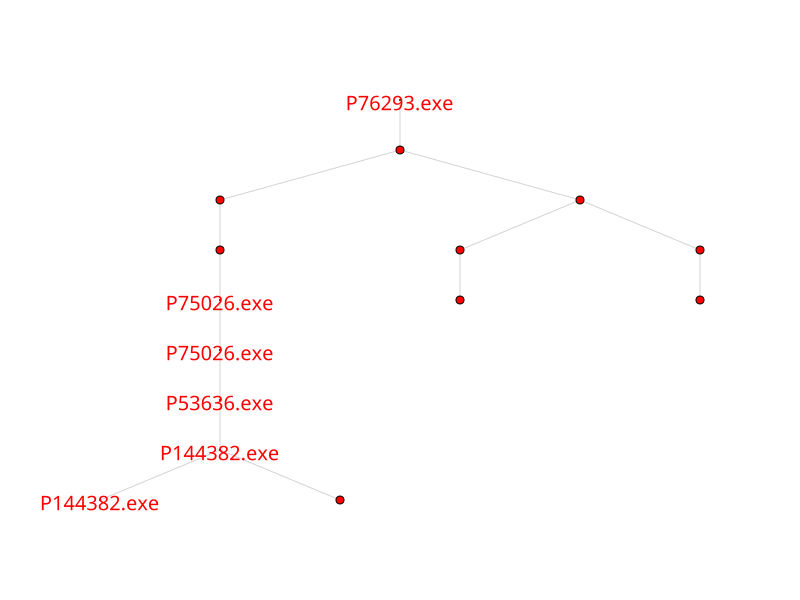

In [17]:
## plot malicious tree; highlight path
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 8
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 20
print('number of nodes:',sg1.vcount())
ly = sg1.layout_reingold_tilford()
ig.plot(sg1, 
        bbox=(800,600), margin=100, layout=ly,
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['process'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


number of nodes: 8


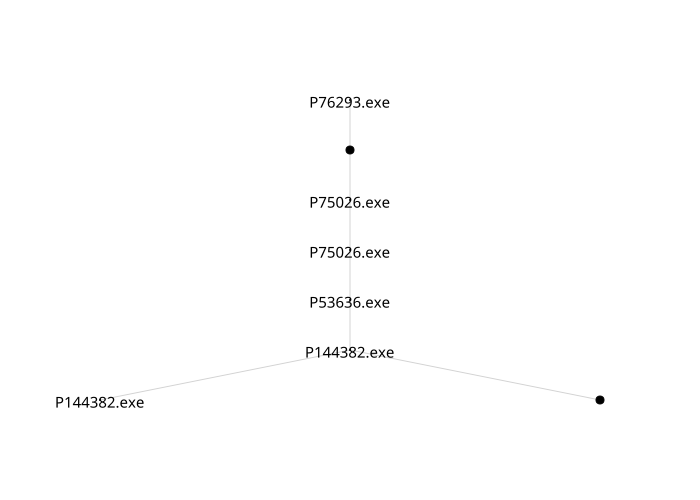

In [18]:
## plot matching non-malicious tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 8
sg2.vs['vertex_label_size'] = 0
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 15
print('number of nodes:',sg2.vcount())
ly = sg2.layout_reingold_tilford()
ig.plot(sg2,
        bbox=(700,500), layout=ly, margin=100, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['process'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


## Next we consider the "test" field


In [19]:
## select trees of depth 3+
train_trees = list(_df[ (_df.depth>=3) & (_df.test == 0) ]['tree'])
test_trees = list(_df[ (_df.depth>=3) & (_df.test > 0) ]['tree'])


In [20]:
%%time
Graphs = []
TreeData = []
n_train = 0
n_test = 0

for i in train_trees:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        Graphs.append(sg)
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        n_train += 1

for i in test_trees:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        Graphs.append(sg)
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        n_test += 1


CPU times: user 4min 45s, sys: 244 ms, total: 4min 46s
Wall time: 4min 46s


In [21]:
%%time
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]

## compare all 
Sim = np.zeros(shape=(n_train, n_test))
Paths = []
for i in range(n_train):
    for j in range(n_test):
        _, score = fast.predict_encoded(enc[i], enc[j+n_train])
        Sim[i,j] = score

Sim.shape


CPU times: user 14min 14s, sys: 257 ms, total: 14min 15s
Wall time: 14min 15s


(4964, 4861)

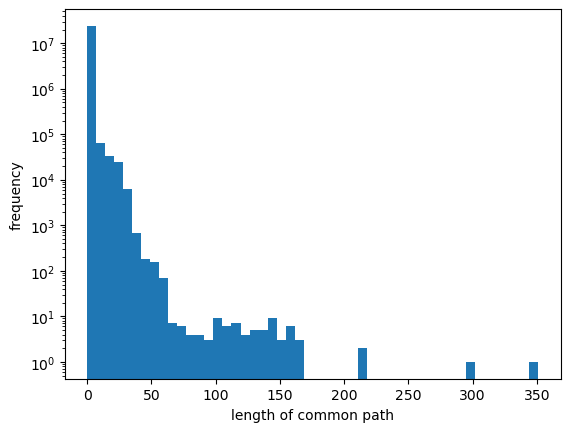

In [22]:
plt.hist(Sim.flatten(), log=True, bins=50)
plt.xlabel('length of common path')
plt.ylabel('frequency');


In [23]:
## pick top similarity pair and visualize common path
(bad, nonbad) = np.unravel_index(np.argmax(Sim), Sim.shape)
sg1 = Graphs[bad]
sg2 = Graphs[nonbad+n_train]
_sg2 = igio.igraph_to_treedata(sg2, phi_name='process')
_sg1 = igio.igraph_to_treedata(sg1, phi_name='process')
fast = fm.FastTreePathMatcher()
fast.fit(_sg1,_sg2)
paths, score = fast.predict()

print('length of matching path:',score)


length of matching path: 351.0


number of nodes: 1318


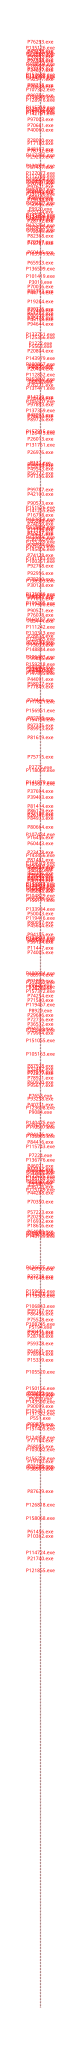

In [24]:
## plot tree with baduser ; highlight path
path = [int(x[0]) for x in paths]
sg1.vs['vertex_size'] = 1
sg1.vs['vertex_label_size'] = 1
for i in path:
    sg1.vs[i]['vertex_size'] = 1
    sg1.vs[i]['vertex_label_size'] = 12
print('number of nodes:',sg1.vcount())
ly = sg1.layout_reingold_tilford()
ig.plot(sg1, 
        bbox=(200,5000), margin=100, layout=ly,
        vertex_size=sg1.vs['vertex_size'], 
        vertex_label=sg1.vs['process'], 
        vertex_label_size=sg1.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


number of nodes: 999


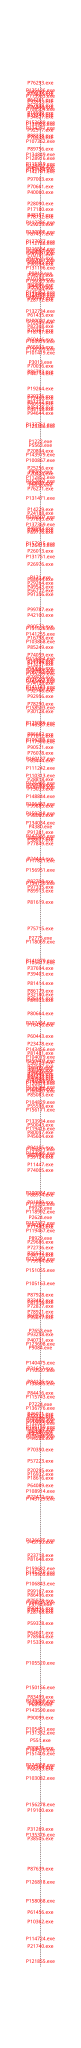

In [25]:
## plot top scoring tree
path = [int(x[1]) for x in paths]
sg2.vs['vertex_size'] = 1
sg2.vs['vertex_label_size'] = 0
for i in path:
    sg2.vs[i]['vertex_size'] = 1
    sg2.vs[i]['vertex_label_size'] = 12 
print('number of nodes:',sg2.vcount())
ly = sg2.layout_reingold_tilford()
ig.plot(sg2,
        bbox=(200,5000), layout=ly, margin=200, 
        vertex_size=sg2.vs['vertex_size'], 
        vertex_label=sg2.vs['process'], 
        vertex_label_size=sg2.vs['vertex_label_size'], 
        edge_color='lightgrey', edge_arrow_size=0)


### quick performance test - vary the number of comparisons exponentially
 

In [26]:
import time
_X = []
_Y = []
for N in [int(np.round(np.sqrt(2**i))) for i in np.arange(11,25)]: ## 22    
          
    before = time.time()
    Graphs = []
    TreeData = []
    n_train = 0
    n_test = 0

    for i in train_trees[:N]:
        
        sg = Trees.subgraph(i)
        if sg.vcount() == (sg.ecount()+1):
            Graphs.append(sg)
            TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
            n_train += 1

    for i in test_trees[:N]:
        sg = Trees.subgraph(i)
        if sg.vcount() == (sg.ecount()+1):
            Graphs.append(sg)
            TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
            n_test += 1

    ## encode all trees
    fast = fm.FastTreePathMatcher()
    fast.fit_encoder(TreeData)
    enc = [fast.encode_tree(t) for t in TreeData]

    ## compare all high scoring with every template
    Sim = np.zeros(shape=(n_train, n_test))
    Paths = []
    for i in range(n_train):
        for j in range(n_test):
            _, score = fast.predict_encoded(enc[i], enc[j+n_train])
            Sim[i,j] = score
    _X.append(N*N)
    _Y.append(time.time()-before)


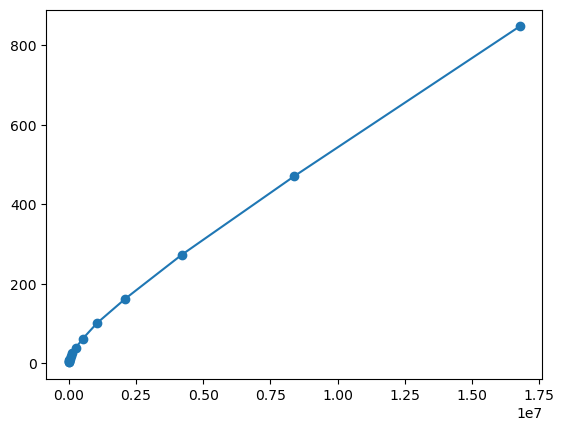

In [27]:
plt.plot(_X,_Y,'o-');

## Classification with random templates


In [28]:
min_depth = 3
n_template = 128
train_trees = list(_df[ (_df.depth>=min_depth) & (_df.test == 0) ]['tree'])
test_trees = list(_df[ (_df.depth>=min_depth) & (_df.test > 0) ]['tree'])
templates = np.random.choice(train_trees, n_template, replace=False)
train_trees = list(set(train_trees).difference(set(templates)))


In [29]:
Graphs = []
TreeData = []
n_templates = 0
n_train = 0
n_test = 0

drop = []

for i in templates:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        Graphs.append(sg)
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        n_templates += 1
    else:
        drop.append(i)
        
for i in train_trees:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        Graphs.append(sg)
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        n_train += 1
    else:
        drop.append(i)
        
for i in test_trees:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        Graphs.append(sg)
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        n_test += 1
    else:
        drop.append(i)


In [30]:
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]


In [31]:
## compare all 
Sim = np.zeros(shape=(n_templates, n_train+n_test))
Paths = []
for i in range(n_templates):
    for j in range(n_train):
        _, score = fast.predict_encoded(enc[i], enc[j+n_templates])
        Sim[i,j] = score
    for j in range(n_test):
        _, score = fast.predict_encoded(enc[i], enc[j+n_templates+n_train])
        Sim[i,j+n_train] = score
Sim.shape


(128, 9697)

In [32]:
X = Sim.T.tolist()

X_train = X[:n_train]
X_test = X[n_train:(n_train+n_test)]

tree_label = dict(zip(_df.tree,_df.has_malicious))
y_train = [tree_label[i] for i in train_trees if i not in drop]
y_test = [tree_label[i] for i in test_trees if i not in drop]


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=16, random_state=123)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


AUC: 0.9325673391750878


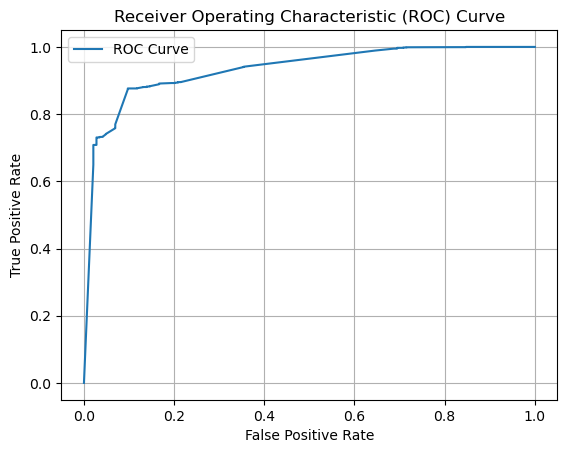

In [34]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()


## classification - chosen templates from training set

In [35]:
min_depth = 3
train_trees = list(_df[ (_df.depth>=min_depth) & (_df.test == 0) ]['tree'])
test_trees = list(_df[ (_df.depth>=min_depth) & (_df.test > 0) ]['tree'])
tree_label = dict(zip(_df.tree,_df.has_malicious))


In [36]:
## encode dataset and save labels
TreeData = []
labels = []

## training
n_train = 0
for i in train_trees:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        labels.append(tree_label[i])
        n_train += 1

## testing 
n_test = 0
for i in test_trees:
    sg = Trees.subgraph(i)
    if sg.vcount() == (sg.ecount()+1):
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='process'))
        labels.append(tree_label[i])
        n_test += 1

## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]


In [37]:
## first batch
batch_size = 16
training = list(range(n_train))
templates = np.random.choice(training, batch_size, replace=False).tolist()
training = list(set(training).difference(set(templates)))

In [38]:
### ...
for _rep in range(7):
    ## compare all and add new batch
    Sim = np.zeros(shape=(len(templates), len(training))) 
    for i in range(len(templates)):
        for j in range(len(training)):
            _, score = fast.predict_encoded(enc[templates[i]], enc[training[j]])
            Sim[i,j] = score
    ## new batch
    new_batch = [training[i] for i in np.argsort(Sim.max(axis=0))[:batch_size]] ## could play here
    templates.extend(new_batch)
    training = list(set(training).difference(set(templates)))


In [39]:
Sim = np.zeros(shape=(len(templates), len(training))) 
for i in range(len(templates)):
    for j in range(len(training)):
        _, score = fast.predict_encoded(enc[templates[i]], enc[training[j]])
        Sim[i,j] = score
X_train = Sim.T.tolist()
y_train = [labels[i] for i in training]


In [40]:
rf = RandomForestClassifier(n_jobs=2, random_state=123)
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
Sim = np.zeros(shape=(len(templates), n_test)) 
for i in range(len(templates)):
    for j in range(n_test):
        _, score = fast.predict_encoded(enc[templates[i]], enc[n_train+j])
        Sim[i,j] = score
X_test = Sim.T.tolist()
y_test = labels[n_train:]


AUC: 0.9416752055214002


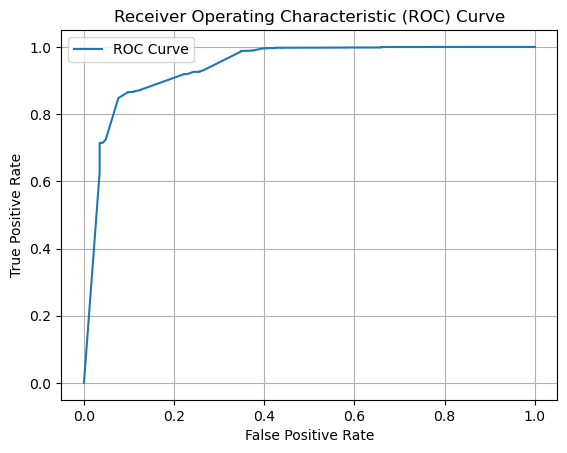

In [42]:
y_pred_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('AUC:',auc(fpr, tpr))

plt.plot(fpr, tpr, label='ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()
